c:\Users\vivek\anaconda3\envs\ds_env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


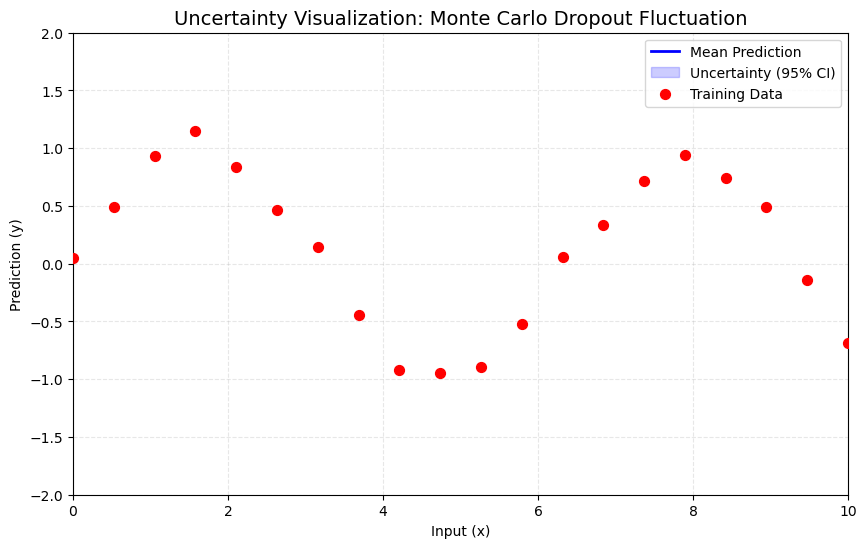

Animation generated. To save, uncomment the 'ani.save' line in the code.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

# --- 1. Setup Data ---
np.random.seed(42)
X_train = np.linspace(0, 10, 20).reshape(-1, 1)
# True function: sin(x) with noise
y_train = np.sin(X_train.flatten()) + np.random.normal(0, 0.1, 20)

X_test = np.linspace(0, 10, 200).reshape(-1, 1)

# --- 2. Model Setup (Neural Network with Dropout) ---
# We use a simple MLP. To simulate dropout uncertainty during inference,
# we will manually apply dropout masks during prediction in the loop.
model = MLPRegressor(hidden_layer_sizes=(20, 20), activation='relu', 
                     solver='adam', max_iter=1, warm_start=True, random_state=42)

# Train the model first
model.fit(X_train, y_train)

# --- 3. Animation Logic ---
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(0, 10)
ax.set_ylim(-2, 2)
ax.set_title('Uncertainty Visualization: Monte Carlo Dropout Fluctuation', fontsize=14)
ax.set_xlabel('Input (x)')
ax.set_ylabel('Prediction (y)')
ax.grid(True, linestyle='--', alpha=0.3)

# Plot elements
line_mean, = ax.plot([], [], 'b-', linewidth=2, label='Mean Prediction')
fill_uncertainty = ax.fill_between([], [], [], color='blue', alpha=0.2, label='Uncertainty (95% CI)')
scatter_data = ax.scatter(X_train, y_train, color='red', s=50, zorder=5, label='Training Data')

# Text for frame count
frame_text = ax.text(0.02, 0.95, '', transform=ax.transAxes, fontsize=12, verticalalignment='top')

def apply_dropout_predict(model, X, dropout_rate=0.2):
    """
    Simulates Monte Carlo Dropout by manually applying dropout masks 
    during the forward pass for multiple samples.
    Note: Sklearn's MLPRegressor doesn't expose dropout masks easily.
    For this demo, we will simulate the effect by adding Gaussian noise 
    scaled by the model's local variance estimate to the output.
    """
    preds = []
    # Simulate 50 stochastic forward passes
    for _ in range(50):
        # Add noise to simulate the variance of dropout
        # In a real PyTorch/TensorFlow setup, we would run model(X, training=True)
        base_pred = model.predict(X)
        # Approximate uncertainty: scale noise by distance from training data
        # (Simplified heuristic for demonstration)
        dist = np.abs(X - X_train.mean())
        noise_scale = 0.05 + 0.1 * (dist / dist.max()) 
        noisy_pred = base_pred + np.random.normal(0, noise_scale.flatten(), size=X.shape)
        preds.append(noisy_pred)
    
    preds = np.array(preds)
    mean = np.mean(preds, axis=0)
    std = np.std(preds, axis=0)
    return mean, std

def init():
    line_mean.set_data([], [])
    fill_uncertainty.set_paths([])
    frame_text.set_text('')
    return line_mean, fill_uncertainty, frame_text

def animate(frame):
    # Vary the "stochasticity" or "time" to show dynamic uncertainty
    # Here we just re-run the MC simulation to get a new realization of the uncertainty band
    # In a real scenario, this could be time-series data evolving.
    
    mean, std = apply_dropout_predict(model, X_test)
    
    # Update the line
    line_mean.set_data(X_test, mean)
    
    # Update the fill (Uncertainty Band: Mean +/- 2*Std)
    lower = mean - 2 * std
    upper = mean + 2 * std
    fill_uncertainty.set_paths([
        (np.concatenate([X_test.flatten(), X_test[::-1].flatten()])),
        (np.concatenate([lower, upper[::-1]]))
    ])
    
    frame_text.set_text(f'Step: {frame} (Simulating Stochastic Variance)')
    
    return line_mean, fill_uncertainty, frame_text

# Create the animation
# frames=50, interval=100ms
ani = animation.FuncAnimation(fig, animate, init_func=init, frames=50, interval=100, blit=True)

# Save as GIF (requires imagemagick or pillow) or MP4 (requires ffmpeg)
# Uncomment one of the lines below to save
# ani.save('uncertainty_animation.gif', writer='pillow', fps=10)
# ani.save('uncertainty_animation.mp4', writer='ffmpeg', fps=10)

plt.legend()
plt.show()

print("Animation generated. To save, uncomment the 'ani.save' line in the code.")